# Ribo-seq analysis from global BAM + Zarr

**Load once, query instantly.** Reads the entire BAM and GTF into memory,
does a single overlap join, then all downstream analyses (gene profiles,
count matrices, metagenes, clustering, range scoring) are in-memory operations.

## Setup

Requires **Python 3.12+** (pyranges1 uses PEP 695 syntax). Create a clean conda env:

```bash
# From the notebooks/ directory
conda env create -f environment.yml
conda activate riboseq-analysis
python -m ipykernel install --user --name riboseq-analysis --display-name "Ribo-seq (Python 3.12)"
```

Then select the **"Ribo-seq (Python 3.12)"** kernel in Jupyter.

In [7]:
# === EDIT THESE PATHS ===
BAM_PATH = "/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/results/global/unique_reads.bam"
ZARR_PATH = "/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/results/global/global_matrix.zarr"
GTF_PATH = "/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/zebrafish_references/zebrafish_grcz12tu/GRCz12tu/danio_rerio_gca049306965v1.gtf"  # Ensembl GTF used for STAR index

# Optional: P-site offset file from RiboWaltz (tab-delimited: length\toffset)
OFFSET_FILE = None  # e.g., "/path/to/psite_offsets.tsv"

# Gene to examine
GENE_NAME = "ACTB"  # or use GENE_ID below
GENE_ID = "ENSDARG00160006181"       # e.g., "ENSG00000075624" — takes priority over GENE_NAME if set

# Samples to compare (None = all samples)
SAMPLES = None  # e.g., ["SRR1234567", "SRR7654321"]

In [9]:
import numpy as np
import pandas as pd
import polars as pl
import zarr
import pyranges1 as pr
import matplotlib.pyplot as plt
import time
from pathlib import Path
from collections import defaultdict

try:
    import biobear as bb
    HAS_BIOBEAR = True
except ImportError:
    import pysam
    HAS_BIOBEAR = False
    print("biobear not found — falling back to pysam (slower)")

## Helpers

In [31]:
# ── GTF parsing ─────────────────────────────────────────────────────

def _parse_attrs(s):
    d = {}
    for f in s.strip().split(';'):
        f = f.strip()
        if not f: continue
        k, _, v = f.partition(' ')
        d[k] = v.strip('"')
    return d


def parse_gtf(gtf_path):
    """
    Parse GTF into two polars DataFrames:
      genes_pl:    gene_id, gene_name, Chromosome, Start, End, Strand
      features_pl: gene_id, feature, Chromosome, Start, End, Strand
    """
    genes, feats = [], []
    with open(gtf_path) as f:
        for line in f:
            if line.startswith('#'): continue
            c = line.strip().split('\t')
            if len(c) < 9: continue
            feat = c[2]
            a = _parse_attrs(c[8])
            s, e = int(c[3]) - 1, int(c[4])  # 0-based half-open
            if feat == 'gene':
                genes.append((a.get('gene_id',''), a.get('gene_name',''),
                              c[0], s, e, c[6]))
            elif feat in ('exon', 'CDS'):
                feats.append((a.get('gene_id',''), feat, c[0], s, e, c[6]))
    genes_pl = pl.DataFrame(
        genes, schema=['gene_id','gene_name','Chromosome','Start','End','Strand'],
        orient='row')
    features_pl = pl.DataFrame(
        feats, schema=['gene_id','feature','Chromosome','Start','End','Strand'],
        orient='row')
    return genes_pl, features_pl


# ── BAM reading ────────────────────────────────────────────────────

def read_bam_biobear(bam_path):
    session = bb.connect()
    session.sql(f"""
        CREATE EXTERNAL TABLE _bam STORED AS BAM LOCATION '{bam_path}'
    """)
    raw = session.sql("""
        SELECT name, flag, reference, start, "end" FROM _bam
    """).to_polars()
    return (
        raw.filter(
            (pl.col('flag').and_(4) == 0) &    # mapped
            (pl.col('flag').and_(256) == 0) &   # primary
            (pl.col('flag').and_(2048) == 0)     # not supplementary
        )
        .filter(pl.col('name').str.starts_with('read_'))
        .with_columns(
            pl.col('name').str.strip_prefix('read_').cast(pl.Int64).alias('global_id'),
            pl.when(pl.col('flag').and_(16) > 0)
              .then(pl.lit('-')).otherwise(pl.lit('+')).alias('Strand'),
        )
        .rename({'reference': 'Chromosome', 'start': 'Start', 'end': 'End'})
        .select(['global_id', 'Chromosome', 'Start', 'End', 'Strand'])
    )


def read_bam_pysam(bam_path):
    """Fallback: single sequential pass with pysam."""
    rows = []
    with pysam.AlignmentFile(bam_path, 'rb') as bam:
        for r in bam.fetch(until_eof=True):
            if r.is_unmapped or r.is_secondary or r.is_supplementary:
                continue
            if not r.query_name.startswith('read_'):
                continue
            rows.append((
                int(r.query_name.split('_')[1]),
                r.reference_name,
                r.reference_start,
                r.reference_end,
                '-' if r.is_reverse else '+',
            ))
    return pl.DataFrame(
        rows, schema=['global_id','Chromosome','Start','End','Strand'],
        orient='row')


# ── Offsets ─────────────────────────────────────────────────────────

def load_offsets(path):
    d = {}
    with open(path) as f:
        next(f)
        for line in f:
            l, o = line.strip().split('\t')
            d[int(l)] = int(o)
    return d


# ── Plotting ────────────────────────────────────────────────────────

def plot_profiles(profiles, tx_length, cds_start, cds_end,
                  sample_names, title='', max_samples=6, normalise=False):
# 1. Filter for valid profiles (sum > 0)
    valid_data = []
    for i, y in enumerate(profiles):
        y_float = y.astype(float)
        if y_float.sum() > 200:
            # Apply normalisation (RPM) if requested
            if normalise:
                y_float = (y_float / y_float.sum()) * 1e6
            valid_data.append((sample_names[i], y_float))
    
    # Limit to max_samples
    valid_data = valid_data[:max_samples]
    n = len(valid_data)
    
    if n == 0:
        print("No valid profiles with counts found.")
        return None

    # Setup figure
    ratios = [3] * n + [0.5]
    fig, axes = plt.subplots(
        n + 1, 1, figsize=(14, 2.2 * n + 1),
        gridspec_kw=dict(height_ratios=ratios, hspace=0.25), sharex=True)
    
    # Ensure axes is iterable even if n=1 (excluding the annotation track)
    if n == 1:
        axes = [axes[0], axes[1]]
        
    x = np.arange(tx_length)
    
    # 2. Plot A-site bar charts
    for i in range(n):
        ax = axes[i]
        name, y = valid_data[i]
        
        # Use bar instead of fill_between for discrete A-site counts
        ax.bar(x, y, color='#2c7fb8', width=1.0, align='edge', alpha=0.9, linewidth=0)
        
        # Highlights for CDS region
        ax.axvspan(cds_start, cds_end, alpha=0.06, color='green', zorder=0)
        if cds_start > 0:
            ax.axvline(cds_start, color='green', lw=0.8, ls='--', alpha=0.5)
        if cds_end < tx_length:
            ax.axvline(cds_end, color='red', lw=0.8, ls='--', alpha=0.5)
            
        ax.set_ylabel('RPM' if normalise else 'Count', fontsize=9)
        ax.set_title(name, fontsize=10, loc='left', pad=2)
        ax.spines[['top', 'right']].set_visible(False)
    
    # 3. Annotation track (the gene model at the bottom)
    a = axes[-1]
    a.plot([0, tx_length], [.5, .5], color='#333', lw=2, solid_capstyle='butt')
    if cds_end > cds_start:
        a.add_patch(plt.Rectangle((cds_start, .2), cds_end-cds_start, .6,
                                  fc='#2c7fb8', ec='#333', lw=1, zorder=3))
        a.text((cds_start+cds_end)/2, .5, 'CDS', ha='center', va='center',
               fontsize=9, fontweight='bold', color='white', zorder=4)
    
    if cds_start > 0:
        a.text(cds_start/2, .5, "5'UTR", ha='center', va='center', fontsize=8, color='#555')
    if cds_end < tx_length:
        a.text((cds_end+tx_length)/2, .5, "3'UTR", ha='center', va='center', fontsize=8, color='#555')
        
    a.set_xlim(0, tx_length)
    a.set_ylim(0, 1)
    a.axis('off')
    
    axes[-2].set_xlabel("Transcript position (nt, 5'→3')", fontsize=11)
    if title: 
        fig.suptitle(title, fontsize=13, fontweight='bold')
        
    plt.tight_layout()
    return fig


print('Helpers loaded ✓')

Helpers loaded ✓


---
## Load everything (run once)

In [11]:
t0 = time.time()

# ── A. BAM → polars ────────────────────────────────────────────────
print('Reading BAM...', flush=True)
reads_pl = read_bam_biobear(BAM_PATH) if HAS_BIOBEAR else read_bam_pysam(BAM_PATH)
print(f'  {len(reads_pl):,} aligned reads  [{time.time()-t0:.0f}s]')

# ── B. GTF → polars ────────────────────────────────────────────────
print('Parsing GTF...', flush=True)
genes_pl, features_pl = parse_gtf(GTF_PATH)
print(f'  {len(genes_pl):,} genes, {len(features_pl):,} exon/CDS features')

# ── C. Overlap join ────────────────────────────────────────────────
print('Overlap join (reads × genes)...', flush=True)
reads_pr = pr.PyRanges(
    reads_pl.select(['Chromosome','Start','End','Strand','global_id']).to_pandas())
genes_pr = pr.PyRanges(genes_pl.to_pandas())
overlap_pr = genes_pr.join_overlaps(reads_pr, strand_behavior='same')
overlap_df = pl.from_pandas(pd.DataFrame(overlap_pr))
print(f'  {len(overlap_df):,} read-gene overlaps  [{time.time()-t0:.0f}s]')

# ── D. Zarr + samples ──────────────────────────────────────────────
root = zarr.open(ZARR_PATH, mode='r')
counts = root['counts']
sample_names = list(root.attrs['samples'])
chunk_size = counts.chunks[0]

if SAMPLES:
    sample_idx = np.array([sample_names.index(s) for s in SAMPLES])
    sel_samples = SAMPLES
else:
    sample_idx = np.arange(len(sample_names))
    sel_samples = sample_names

n_samples = len(sel_samples)
print(f'  Zarr: {counts.shape[0]:,} reads × {counts.shape[1]:,} samples')
print(f'  Selected {n_samples} samples')
print(f'\n✓ Ready  [{time.time()-t0:.0f}s total]')

Reading BAM...
  22,677,115 aligned reads  [21s]
Parsing GTF...
  54,881 genes, 850,951 exon/CDS features
Overlap join (reads × genes)...
  19,441,842 read-gene overlaps  [48s]
  Zarr: 38,982,435 reads × 292 samples
  Selected 292 samples

✓ Ready  [48s total]


---
## Gene × sample count matrix (single zarr pass)

In [12]:
t0 = time.time()

# Group overlaps: gene_id → sorted list of global_ids
gene_reads_map = (
    overlap_df
    .select(['gene_id', 'global_id'])
    .unique()
    .sort('global_id')
    .group_by('gene_id')
    .agg(pl.col('global_id'))
)

gene_ids_list = gene_reads_map['gene_id'].to_list()
gene_id_to_idx = {g: i for i, g in enumerate(gene_ids_list)}
n_genes = len(gene_ids_list)

# Reverse index: global_id → list of gene matrix row indices
gid_to_gene_rows = defaultdict(list)
for row in gene_reads_map.iter_rows():
    gene_id, gids = row
    gi = gene_id_to_idx[gene_id]
    for gid in gids:
        gid_to_gene_rows[gid].append(gi)

needed_ids = np.array(sorted(gid_to_gene_rows.keys()), dtype=np.int64)
print(f'{n_genes:,} genes with reads, {len(needed_ids):,} unique read ids')

# Single sequential pass through zarr chunks
result = np.zeros((n_genes, n_samples), dtype=np.uint64)
n_chunks_read = 0

for chunk_start in range(0, counts.shape[0], chunk_size):
    chunk_end = min(chunk_start + chunk_size, counts.shape[0])
    lo = np.searchsorted(needed_ids, chunk_start, side='left')
    hi = np.searchsorted(needed_ids, chunk_end, side='left')
    if lo >= hi:
        continue

    chunk = counts[chunk_start:chunk_end, :]  # read once
    n_chunks_read += 1

    for idx in range(lo, hi):
        gid = int(needed_ids[idx])
        row_in_chunk = gid - chunk_start
        rc = chunk[row_in_chunk, sample_idx].astype(np.uint64)
        for gene_row in gid_to_gene_rows[gid]:
            result[gene_row, :] += rc

    if n_chunks_read % 200 == 0:
        print(f'  {n_chunks_read} chunks read  [{time.time()-t0:.0f}s]', flush=True)

elapsed = time.time() - t0
print(f'\n✓ {n_genes:,} genes × {n_samples} samples  [{elapsed:.0f}s, {n_chunks_read} chunks]')

# Attach gene names
gene_name_map = dict(zip(
    genes_pl['gene_id'].to_list(), genes_pl['gene_name'].to_list()))
gene_names_list = [gene_name_map.get(g, '') for g in gene_ids_list]

gene_count_df = pd.DataFrame(
    result.astype(np.uint32),
    index=pd.MultiIndex.from_arrays(
        [gene_ids_list, gene_names_list], names=['gene_id','gene_name']),
    columns=sel_samples,
)
gene_count_df.head(10)

34,959 genes with reads, 19,001,572 unique read ids
  200 chunks read  [43s]
  400 chunks read  [54s]
  600 chunks read  [64s]
  800 chunks read  [74s]
  1000 chunks read  [84s]
  1200 chunks read  [94s]
  1400 chunks read  [104s]
  1600 chunks read  [113s]
  1800 chunks read  [121s]
  2000 chunks read  [132s]
  2200 chunks read  [142s]
  2400 chunks read  [152s]
  2600 chunks read  [162s]
  2800 chunks read  [171s]
  3000 chunks read  [182s]
  3200 chunks read  [192s]
  3400 chunks read  [202s]
  3600 chunks read  [213s]
  3800 chunks read  [224s]

✓ 34,959 genes × 292 samples  [227s, 3872 chunks]


,,SRR1062229,SRR1062284,SRR1062248,SRR1062311,SRR1062217,SRR1062198,SRR1062220,SRR1062223,SRR1062226,SRR1062227,...,SRR1062629,SRR1062597,SRR1062785,SRR1062775,SRR1062800,SRR1062609,SRR1062813,SRR1062815,SRR1062623,SRR1062610
gene_id,gene_name,,,,,,,,,,,,,,,,,,,,,
ENSDARG00160038612,,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSDARG00160022687,,0,0,0,0,0,1,1,1,0,2,...,0,0,1,0,0,0,1,0,0,0
ENSDARG00160032884,pvalb2,0,0,0,703,1,0,0,1,6,3,...,2398,2292,3,6,8,2271,6,9,2270,2220
ENSDARG00160015543,,0,0,0,0,2,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
ENSDARG00160034720,KHDRBS2,0,0,0,4,0,2,0,0,0,0,...,4,2,0,1,0,5,0,0,6,8
ENSDARG00160044364,,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSDARG00160012731,mbd1b,0,4,8,7,1,10,2,1,6,4,...,28,16,4,4,8,25,7,10,18,23
ENSDARG00160053586,,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
ENSDARG00160007422,,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1


In [13]:
out = str(Path(ZARR_PATH).parent / 'gene_counts_matrix.tsv')
gene_count_df.to_csv(out, sep='\t')
print(f'Saved to {out}')

Saved to /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/results/global/gene_counts_matrix.tsv


---
## Single-gene profile (instant)

In [24]:
GENE_ID = "ENSDARG00160032884"
# ── Pick gene ──────────────────────────────────────────────────────
if GENE_ID:
    _gf = genes_pl.filter(pl.col('gene_id') == GENE_ID)
else:
    _gf = genes_pl.filter(pl.col('gene_name') == GENE_NAME)
assert len(_gf) > 0, f"Gene not found: {GENE_ID or GENE_NAME}"
gene = _gf.row(0, named=True)

# ── Reads overlapping this gene (from pre-computed join) ──────────
gene_overlap = overlap_df.filter(pl.col('gene_id') == gene['gene_id'])
gene_gids = gene_overlap['global_id'].unique().sort().to_list()
gene_reads = reads_pl.filter(pl.col('global_id').is_in(gene_gids))

# ── Build transcript coord map ────────────────────────────────────
gf = features_pl.filter(pl.col('gene_id') == gene['gene_id'])
exons = [(r[0], r[1]) for r in gf.filter(pl.col('feature')=='exon').select(['Start','End']).iter_rows()]
cdss  = [(r[0], r[1]) for r in gf.filter(pl.col('feature')=='CDS').select(['Start','End']).iter_rows()]
exons = sorted(set(exons)); cdss = sorted(set(cdss))

exon_pos = sorted({p for s,e in exons for p in range(s,e)})
if gene['Strand'] == '-': exon_pos = exon_pos[::-1]
g2tx = {gp: tx for tx, gp in enumerate(exon_pos)}
tx_len = len(exon_pos)

cds_genomic = {p for s,e in cdss for p in range(s,e)}
cds_tx = sorted(g2tx[g] for g in cds_genomic if g in g2tx)
cds_s = cds_tx[0] if cds_tx else 0
cds_e = cds_tx[-1]+1 if cds_tx else 0

# ── Inflate from zarr ──────────────────────────────────────────────
gids_arr = np.array(gene_gids, dtype=np.int64)
id_to_counts = {}
by_chunk = defaultdict(list)
for gid in gids_arr:
    by_chunk[gid // chunk_size].append(gid)
for ci in sorted(by_chunk):
    cs, ce = ci*chunk_size, min((ci+1)*chunk_size, counts.shape[0])
    ch = counts[cs:ce, :]
    for gid in by_chunk[ci]:
        id_to_counts[gid] = ch[gid-cs, sample_idx]

# ── Build profile ──────────────────────────────────────────────────
offsets = load_offsets(OFFSET_FILE) if OFFSET_FILE else None
profiles = np.zeros((n_samples, tx_len), dtype=np.float64)

for row in gene_reads.iter_rows(named=True):
    sc = id_to_counts.get(row['global_id'])
    if sc is None: continue
    alen = row['End'] - row['Start']  # contiguous (no introns, alignIntronMax=1)

    if offsets:
        ofs = offsets.get(alen)
        if ofs is None or ofs >= alen: continue
        if row['Strand'] == '+':
            asite = row['Start'] + ofs
        else:
            asite = row['End'] - 1 - ofs
        ti = g2tx.get(asite)
        if ti is not None:
            profiles[:, ti] += sc
    else:
        for p in range(row['Start'], row['End']):
            ti = g2tx.get(p)
            if ti is not None:
                profiles[:, ti] += sc

print(f"{gene['gene_name']} ({gene['gene_id']})")
print(f"  {gene['Chromosome']}:{gene['Start']:,}-{gene['End']:,} ({gene['Strand']})")
print(f"  {len(gene_gids)} unique reads | tx_len={tx_len} | CDS={cds_s}-{cds_e}")
print(f"  Mode: {'A-site' if offsets else 'coverage'}")

pvalb2 (ENSDARG00160032884)
  12:19,331,670-19,333,747 (-)
  6423 unique reads | tx_len=704 | CDS=147-474
  Mode: coverage


In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

def plot_ribo_kmeans(profiles_matrix, tx_length, cds_start, cds_end, n_clusters=15):
    # 1. Pre-process & Normalize (Required for K-Means)
    data = profiles_matrix.astype(np.float32)
    valid_mask = data.sum(axis=1) > 0
    data = data[valid_mask]
    
    # Unit normalization (0-1) for each row makes clustering focus on shape, not magnitude
    row_max = data.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1 # Avoid division by zero
    data_norm = data / row_max

    # 2. Run K-Means
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(data_norm)
    
    # Sort data by cluster labels to group them in the heatmap
    sort_idx = np.argsort(labels)
    data_sorted = data[sort_idx]
    labels_sorted = labels[sort_idx]

    # 3. Setup Figure
    # Col 0: Cluster ID | Col 1: Main Plots | Col 2: Colorbar
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.5, 4, 0.4], 
                          width_ratios=[0.02, 0.95, 0.03], hspace=0.2, wspace=0.03)
    
    ax_groups = fig.add_subplot(gs[1, 0])
    ax_top    = fig.add_subplot(gs[0, 1])
    ax_hm     = fig.add_subplot(gs[1, 1], sharex=ax_top)
    ax_ann    = fig.add_subplot(gs[2, 1], sharex=ax_top)
    ax_cbar   = fig.add_subplot(gs[1, 2])

    # 4. Plot Cluster Identifiers (the thin colored strip on the left)
    # We use a distinct colormap like 'tab10' for categories
    ax_groups.imshow(labels_sorted.reshape(-1, 1), aspect='auto', cmap='tab10', interpolation='nearest')
    ax_groups.axis('off')

    # 5. Top Plot: Mean profile
    x = np.arange(tx_length)
    ax_top.fill_between(x, 0, np.mean(data_sorted, axis=0), step='mid', color='#2c7fb8', lw=0)
    ax_top.set_ylabel('Mean Signal')
    ax_top.spines[['top', 'right']].set_visible(False)

    # 6. Heatmap
    im = ax_hm.imshow(data_sorted, cmap='viridis', aspect='auto', interpolation='nearest',
                      extent=[0, tx_length, len(data_sorted), 0], rasterized=True)
    ax_hm.set_ylabel(f"Samples grouped into {n_clusters} clusters")
    plt.colorbar(im, cax=ax_cbar)

    # 7. Annotation
    ax_ann.add_patch(plt.Rectangle((cds_start, 0.2), cds_end-cds_start, 0.6, fc='#e67e22', ec='#333'))
    ax_ann.text((cds_start+cds_end)/2, 0.5, 'CDS', ha='center', va='center', fontweight='bold', color='white')
    ax_ann.set_xlim(0, tx_length)
    ax_ann.axis('off')
    
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_hm.get_xticklabels(), visible=False)
    
    return fig

/tmp/ipykernel_75698/1485485022.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


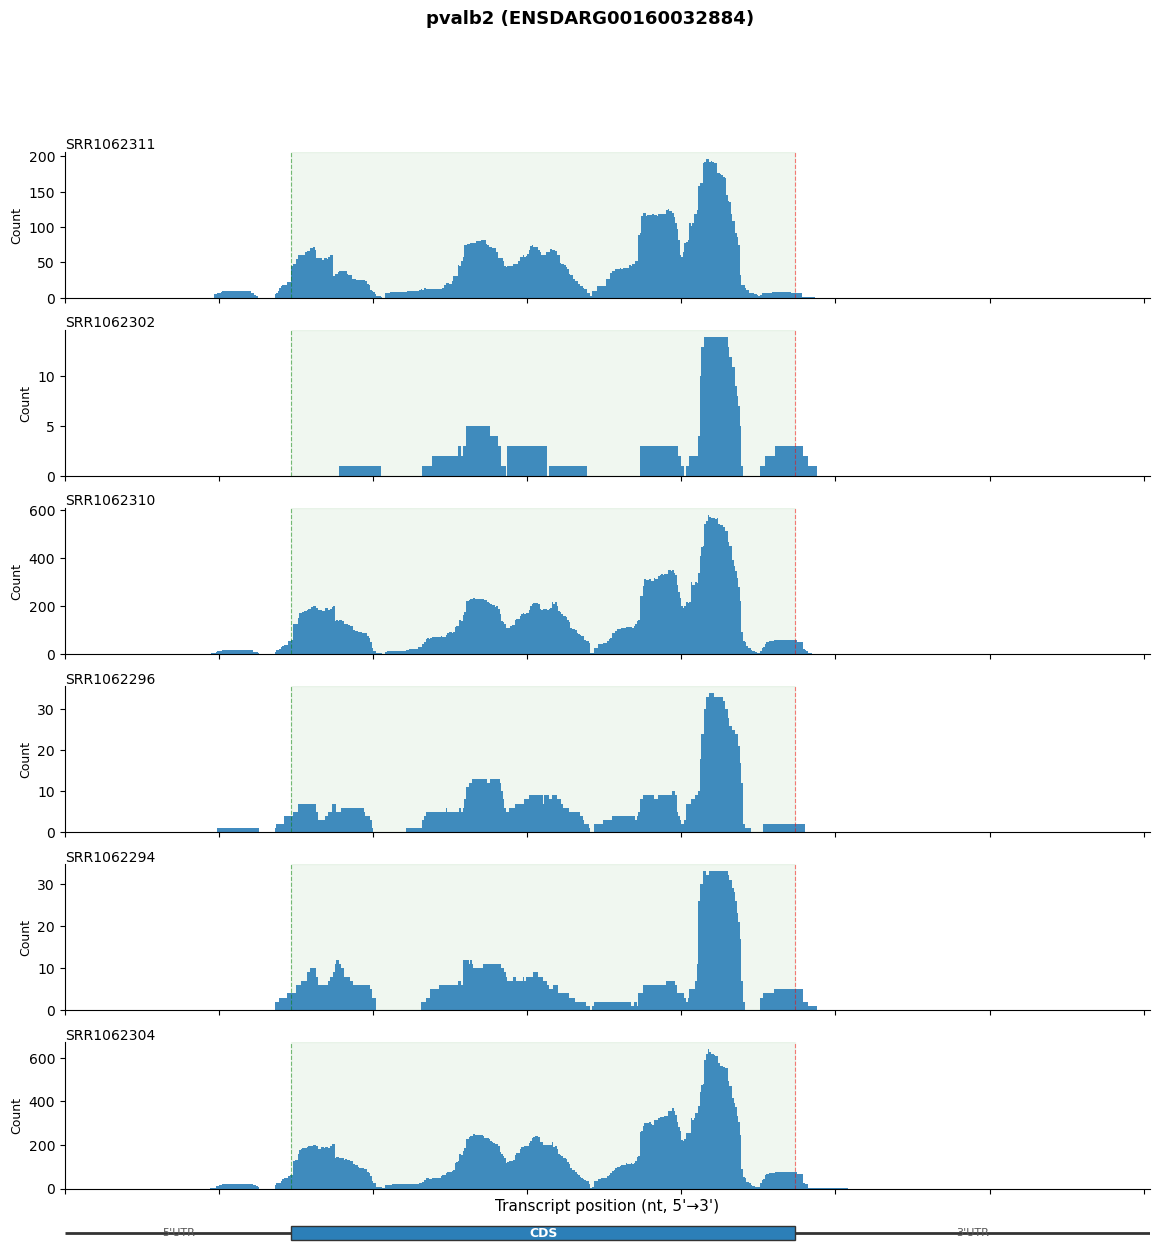

In [32]:
plot_profiles(profiles, tx_len, cds_s, cds_e, sel_samples,
    title=f"{gene['gene_name']} ({gene['gene_id']})");

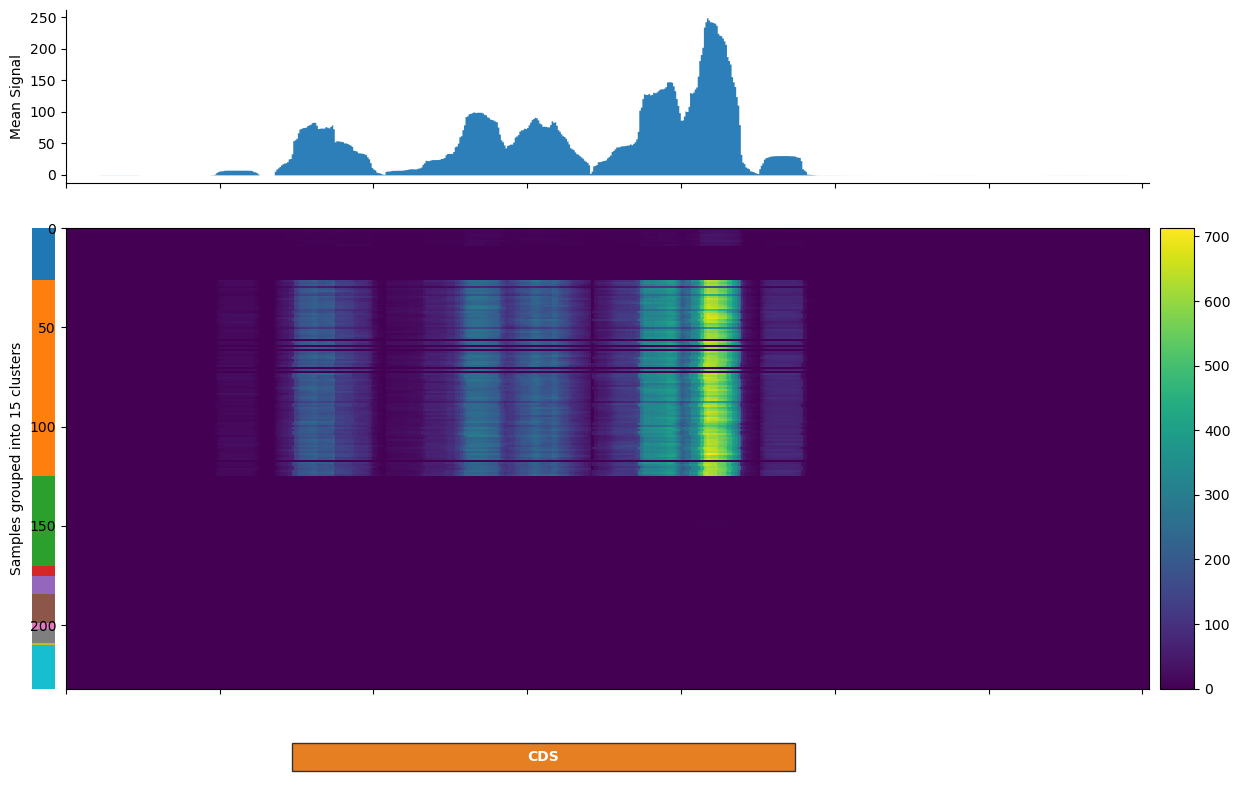

In [53]:
plot_ribo_kmeans(profiles, tx_len, cds_s, cds_e);

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def plot_ribo_dbscan(profiles_matrix, tx_length, cds_start, cds_end, eps=0.9, min_samples=5):
    # 1. Pre-process
    data = profiles_matrix.astype(np.float32)
    valid_mask = data.sum(axis=1) > 200
    data = data[valid_mask]
    
    # Standardize data: DBSCAN relies heavily on distance
    # Scaling ensures that high-magnitude samples don't distort the 'distance'
    data_scaled = StandardScaler().fit_transform(data)

    # 2. Run DBSCAN
    # eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    # min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(data_scaled)
    labels = db.labels_
    
    # Sort data by cluster labels (Noise -1 will be at the top)
    sort_idx = np.argsort(labels)
    data_sorted = data[sort_idx]
    labels_sorted = labels[sort_idx]
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Detected {n_clusters} clusters and {list(labels).count(-1)} noise samples.")

    # 3. Setup Figure
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.5, 4, 0.4], 
                          width_ratios=[0.02, 0.95, 0.03], hspace=0.2, wspace=0.03)
    
    ax_groups = fig.add_subplot(gs[1, 0])
    ax_top    = fig.add_subplot(gs[0, 1])
    ax_hm     = fig.add_subplot(gs[1, 1], sharex=ax_top)
    ax_ann    = fig.add_subplot(gs[2, 1], sharex=ax_top)
    ax_cbar   = fig.add_subplot(gs[1, 2])

    # 4. Cluster Strip (Noise -1 usually shows up as the first color in 'tab10')
    ax_groups.imshow(labels_sorted.reshape(-1, 1), aspect='auto', cmap='tab10', interpolation='nearest')
    ax_groups.axis('off')

    # 5. Top Plot: Mean profile of NON-NOISE samples
    x = np.arange(tx_length)
    signal_mask = labels_sorted != -1
    if any(signal_mask):
        mean_signal = np.mean(data_sorted[signal_mask], axis=0)
    else:
        mean_signal = np.mean(data_sorted, axis=0)
        
    ax_top.fill_between(x, 0, mean_signal, step='mid', color='#2c7fb8', lw=0)
    ax_top.set_ylabel('Mean Signal (Clustered)')
    ax_top.spines[['top', 'right']].set_visible(False)

    # 6. Heatmap
    im = ax_hm.imshow(data_sorted, cmap='viridis', aspect='auto', interpolation='nearest',
                      extent=[0, tx_length, len(data_sorted), 0], rasterized=True)
    ax_hm.set_ylabel("Samples (Noise at top)")
    plt.colorbar(im, cax=ax_cbar)

    # 7. Annotation
    ax_ann.add_patch(plt.Rectangle((cds_start, 0.2), cds_end-cds_start, 0.6, fc='#e67e22', ec='#333'))
    ax_ann.text((cds_start+cds_end)/2, 0.5, 'CDS', ha='center', va='center', fontweight='bold', color='white')
    ax_ann.set_xlim(0, tx_length)
    ax_ann.axis('off')
    
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_hm.get_xticklabels(), visible=False)
    
    return fig

Detected 0 clusters and 105 noise samples.


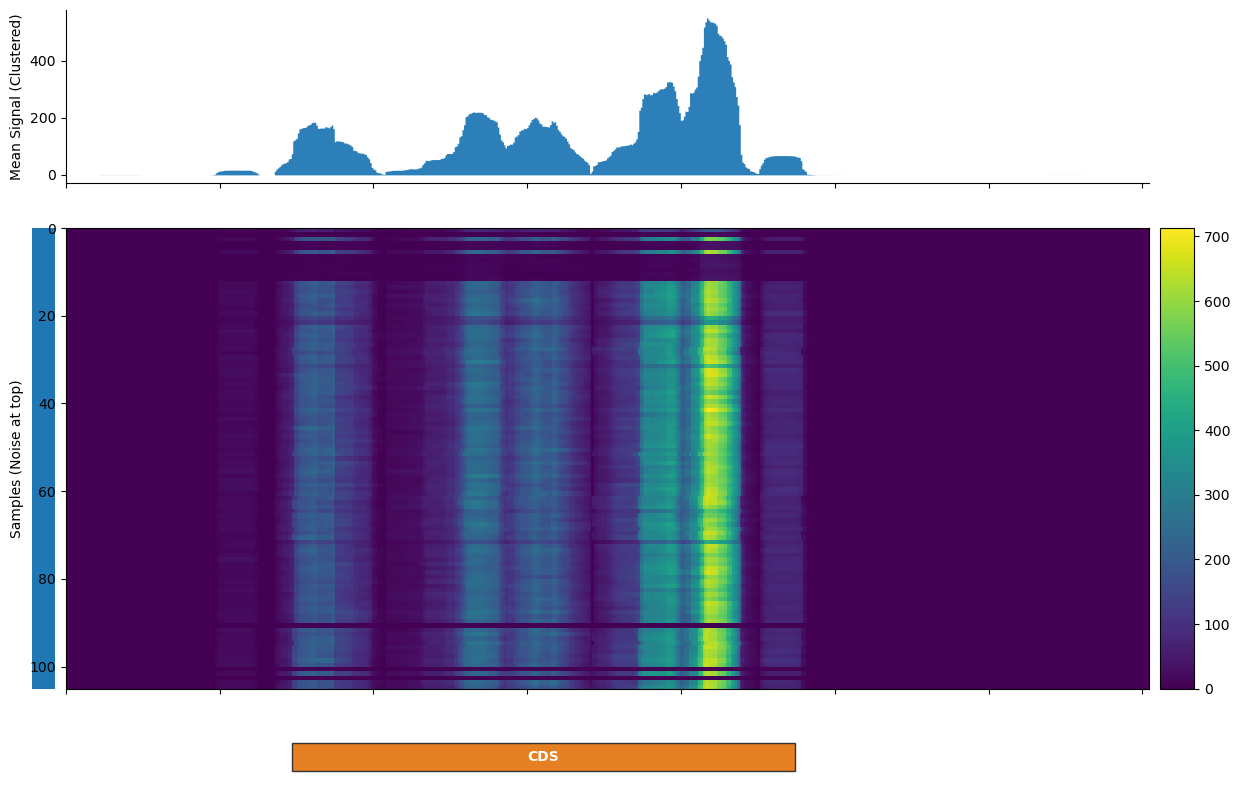

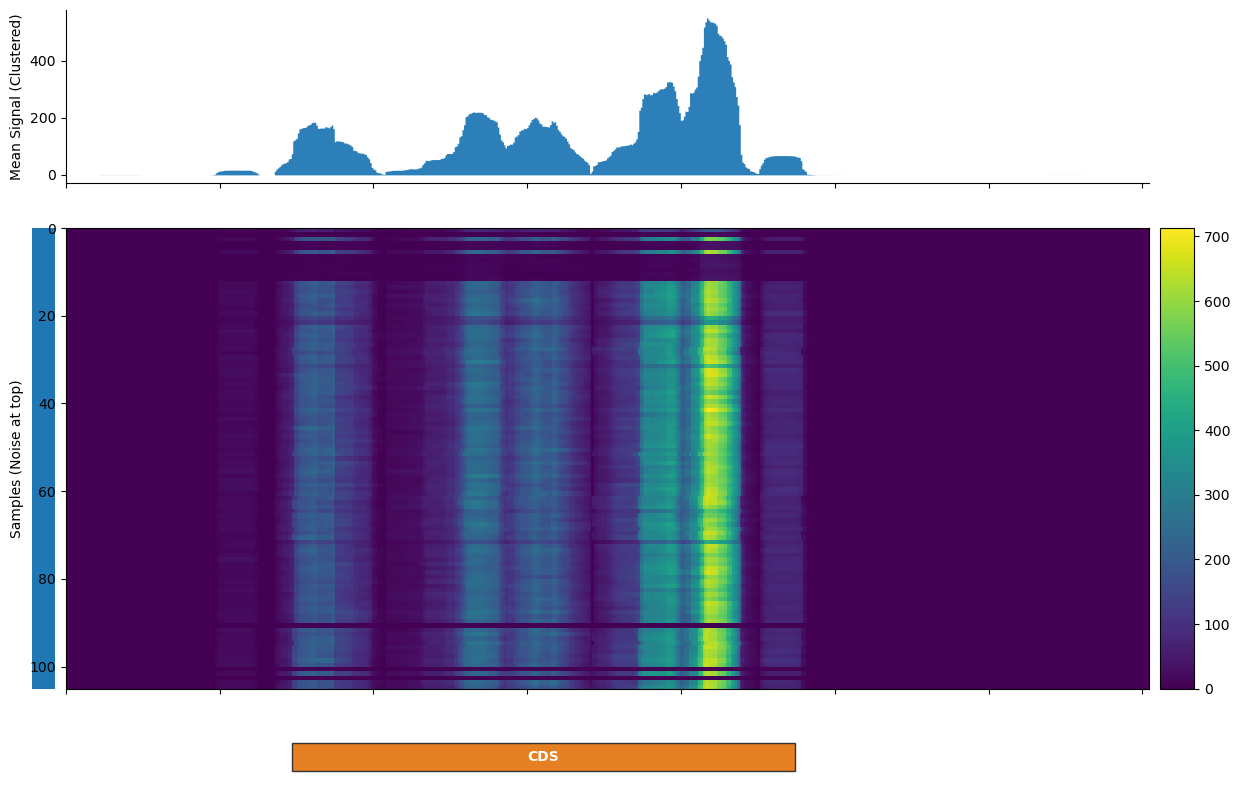

In [59]:
plot_ribo_dbscan(profiles, tx_len, cds_s, cds_e)

/tmp/ipykernel_75698/1485485022.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


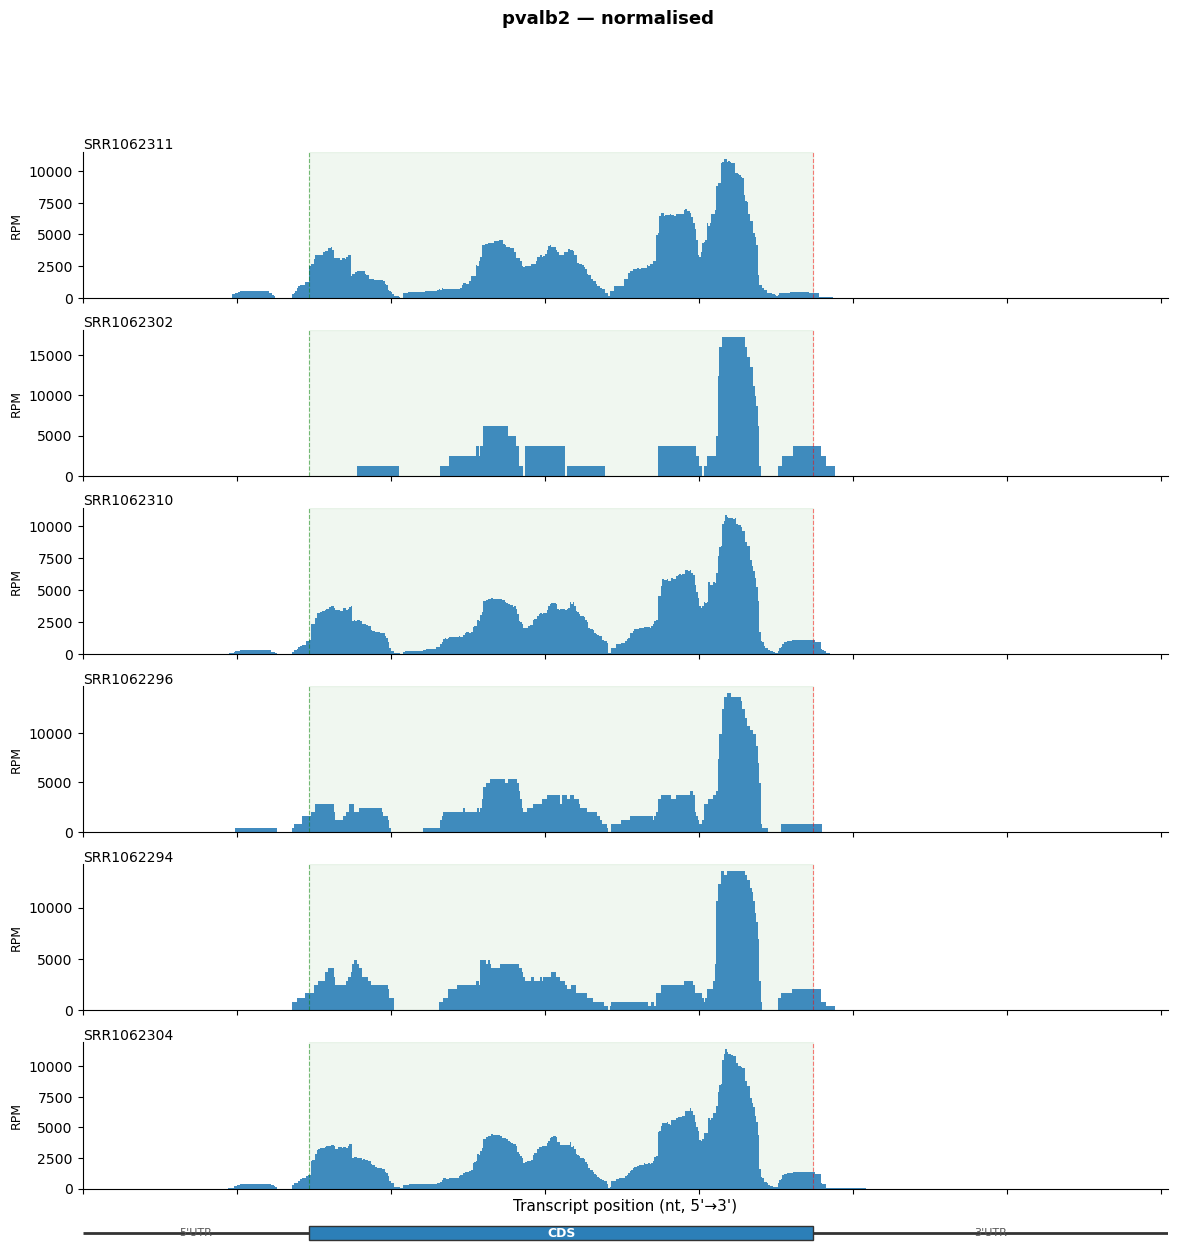

In [60]:
plot_profiles(profiles, tx_len, cds_s, cds_e, sel_samples,
    title=f"{gene['gene_name']} — normalised", normalise=True);

---
## Genome-wide metagene

In [62]:
def calculate_sample_offsets(reads_pl, cds_features, sample_idx):
    """
    Calculates the most frequent offset for a sample by looking at 
    the distance between 5' ends and the Start Codon.
    """
    # 1. Get start codon genomic positions
    starts = cds_features.group_by('gene_id').agg([
        pl.col('Start').min().alias('start_pos'),
        pl.col('Strand').first()
    ])

    # 2. Join reads and calculate distance to Start Codon
    # Distance = Read_Start - Start_Pos (for + strand)
    df = reads_pl.join(starts, on='gene_id')
    df = df.with_columns(
        dist = pl.when(pl.col('Strand') == '+')
               .then(pl.col('Start') - pl.col('start_pos'))
               .otherwise(pl.col('start_pos') - pl.col('End'))
    )

    # 3. Find the peak in the -20 to -10 range (Typical P/A site zone)
    # Most A-sites are ~15nt from the 5' end.
    # At the start codon, the P-site is at 0, so 5' end is usually at -12 or -15.
    offset_dist = (
        df.filter((pl.col('dist') >= -20) & (pl.col('dist') <= -5))
        .group_by('dist')
        .count()
        .sort('count', descending=True)
    )
    
    # The A-site offset is typically abs(peak_dist) + 3 (since P-site is at 0)
    peak = abs(offset_dist['dist'][0])
    return peak

In [63]:
def build_metagene_optimized(reads_pl, cds_features, sample_offsets, n_bins=100):
    meta_acc = np.zeros((len(sample_offsets), n_bins))

    # Pre-calculate CDS lengths for relative positioning
    cds_info = cds_features.group_by('gene_id').agg([
        pl.col('Start').min().alias('c_start'),
        pl.col('End').max().alias('c_end'),
        (pl.col('End').max() - pl.col('Start').min()).alias('c_len'),
        pl.col('Strand').first()
    ]).filter(pl.col('c_len') >= 90)

    for s_idx, offset in enumerate(sample_offsets):
        # Vectorized A-site calculation for this sample
        sample_data = reads_pl.join(cds_info, on='gene_id').with_columns(
            asite = pl.when(pl.col('Strand') == '+')
                    .then(pl.col('Start') + offset)
                    .otherwise(pl.col('End') - offset)
        )

        # Calculate relative position (0 to 1)
        sample_data = sample_data.with_columns(
            rel = (pl.col('asite') - pl.col('c_start')) / pl.col('c_len')
        ).filter((pl.col('rel') >= 0) & (pl.col('rel') <= 1))

        # Weight by gene: To make each gene contribute equally, 
        # we weight each read by 1 / (total reads in that gene)
        gene_counts = sample_data.group_by('gene_id').count()
        sample_data = sample_data.join(gene_counts, on='gene_id')
        weights = 1.0 / sample_data['count'].to_numpy()

        # Fast Binning
        bins = (sample_data['rel'].to_numpy() * (n_bins - 1)).astype(int)
        np.add.at(meta_acc[s_idx], bins, weights)

    return meta_acc

In [82]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import time

def get_sample_offsets(overlap_df, features_pl, counts_zarr, sample_idx):
    """Detects P-site offset by looking at the peak between -18 and -9."""
    starts = features_pl.filter(pl.col('feature') == 'CDS').group_by('gene_id').agg([
        pl.col('Start').min().alias('cds_start'),
        pl.col('End').max().alias('cds_end'),
        pl.col('Strand').first().alias('strand')
    ])

    dist_df = overlap_df.join(starts, on='gene_id').with_columns(
        dist = pl.when(pl.col('strand') == '+')
               .then(pl.col('Start') - pl.col('cds_start'))
               .otherwise(pl.col('cds_end') - pl.col('End'))
    )

    window_df = dist_df.filter((pl.col('dist') >= -25) & (pl.col('dist') <= 5))
    gids = window_df['global_id'].to_numpy()
    dists = window_df['dist'].to_numpy()
    qc_counts = counts_zarr.get_orthogonal_selection((gids, sample_idx))
    
    search_range = np.arange(-18, -8) 
    sample_offsets = []
    
    for i in range(len(sample_idx)):
        dist_signal = np.array([qc_counts[dists == d, i].sum() for d in search_range])
        peak_idx = np.argmax(dist_signal) if dist_signal.sum() > 0 else 6 # default -12
        p_offset = abs(search_range[peak_idx])
        sample_offsets.append(p_offset + 3) # Return A-site offset
        
    return np.array(sample_offsets)

✓ Metagene complete [87.4s]


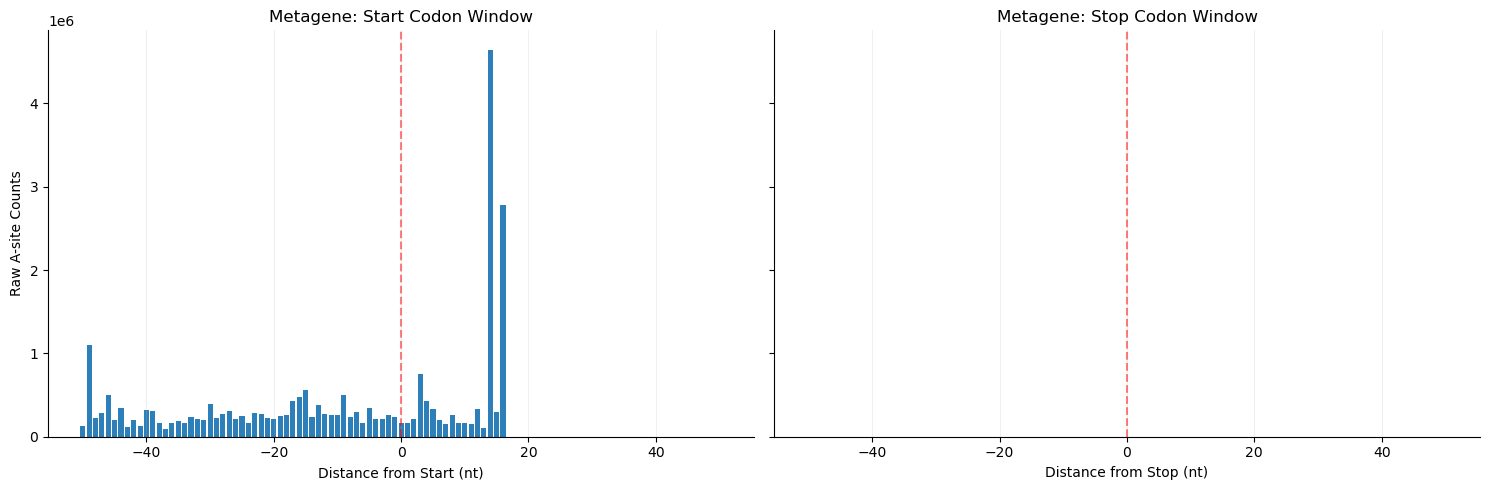

In [85]:
def build_gene_landmarks(features_pl):
    """
    Build gene-level translation start and stop landmarks.
    Uses stop_codon features when present, otherwise CDS boundaries.
    """

    # --- CDS bounds per gene ---
    cds_bounds = (
        features_pl
        .filter(pl.col("feature") == "CDS")
        .group_by("gene_id")
        .agg([
            pl.col("Start").min().alias("cds_start"),
            pl.col("End").max().alias("cds_end"),
            pl.col("Strand").first().alias("strand"),
        ])
    )

    # --- Stop codons (if present) ---
    stop_codons = (
        features_pl
        .filter(pl.col("feature") == "stop_codon")
        .group_by("gene_id")
        .agg([
            pl.col("Start").min().alias("stop_start"),
            pl.col("End").max().alias("stop_end"),
        ])
    )

    landmarks = cds_bounds.join(stop_codons, on="gene_id", how="left")

    landmarks = landmarks.with_columns([
        # Translation start
        pl.when(pl.col("strand") == "+")
          .then(pl.col("cds_start"))
          .otherwise(pl.col("cds_end"))
          .alias("tx_start"),

        # Translation stop
        pl.when(pl.col("strand") == "+")
          .then(
              pl.coalesce(pl.col("stop_start"), pl.col("cds_end") - 3)
          )
          .otherwise(
              pl.coalesce(pl.col("stop_end"), pl.col("cds_start") + 3)
          )
          .alias("tx_stop")
    ])

    return landmarks

def run_fixed_window_metagene(
    overlap_df,
    features_pl,
    counts_zarr,
    sample_idx,
    window=50
):
    t0 = time.time()

    offsets = get_sample_offsets(
        overlap_df, features_pl, counts_zarr, sample_idx
    )

    landmarks = build_gene_landmarks(features_pl)

    size = 2 * window + 1
    start_meta = np.zeros(size)
    stop_meta = np.zeros(size)

    unique_offs = np.unique(offsets)

    for off in unique_offs:
        s_mask = np.where(offsets == off)[0]
        curr_samples = sample_idx[s_mask]

        data = (
            overlap_df
            .join(landmarks, on="gene_id", how="inner")
            .with_columns(
                asite=pl.when(pl.col("strand") == "+")
                    .then(pl.col("Start") + off)
                    .otherwise(pl.col("End") - off)
            )
        )

        # --- Start window ---
        data_start = (
            data
            .with_columns(
                dist=pl.when(pl.col("strand") == "+")
                    .then(pl.col("asite") - pl.col("tx_start"))
                    .otherwise(pl.col("tx_start") - pl.col("asite"))
            )
            .filter(pl.col("dist").is_between(-window, window))
        )

        # --- Stop window ---
        data_stop = (
            data
            .with_columns(
                dist=pl.when(pl.col("strand") == "+")
                    .then(pl.col("asite") - pl.col("tx_stop"))
                    .otherwise(pl.col("tx_stop") - pl.col("asite"))
            )
            .filter(pl.col("dist").is_between(-window, window))
        )

        for sub_data, acc in [(data_start, start_meta), (data_stop, stop_meta)]:
            if sub_data.height == 0:
                continue

            gids = sub_data["global_id"].to_numpy()
            idx = (sub_data["dist"].to_numpy() + window).astype(int)

            counts = (
                counts_zarr
                .get_orthogonal_selection((gids, curr_samples))
                .sum(axis=1)
            )

            np.add.at(acc, idx, counts)

    print(f"✓ Metagene complete [{time.time()-t0:.1f}s]")
    return start_meta, stop_meta, window


# --- EXECUTION & PLOTTING ---
start_m, stop_m, win = run_fixed_window_metagene(overlap_df, features_pl, counts, sample_idx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
x = np.arange(-win, win + 1)



# Start Codon Plot
ax1.bar(x, start_m, color='#2c7fb8', width=0.8)
ax1.axvline(0, color='red', ls='--', alpha=0.5, label='Start (AUG)')
ax1.set_title("Metagene: Start Codon Window")
ax1.set_xlabel("Distance from Start (nt)")
ax1.set_ylabel("Raw A-site Counts")

# Stop Codon Plot
ax2.bar(x, stop_m, color='#e67e22', width=0.8)
ax2.axvline(0, color='red', ls='--', alpha=0.5, label='Stop')
ax2.set_title("Metagene: Stop Codon Window")
ax2.set_xlabel("Distance from Stop (nt)")

for ax in [ax1, ax2]:
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Sample clustering# Execution
fig, metagene_values = run_metagene_pipeline(reads_pl, features_pl)
plt.show()

Variance explained (top 5 PCs): 64.7%


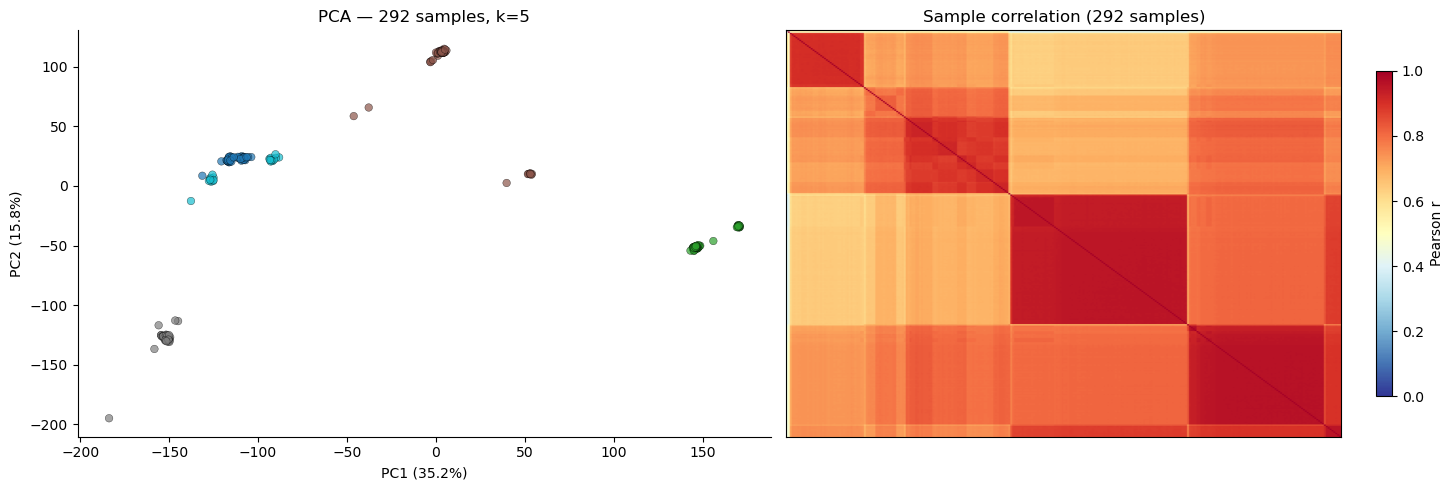

In [65]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Log-normalise the gene count matrix
mat = gene_count_df.values.astype(np.float64).T  # (samples × genes)
lib_sizes = mat.sum(axis=1, keepdims=True).clip(1)
log_cpm = np.log2(mat / lib_sizes * 1e6 + 1)

# PCA
pca = PCA(n_components=min(20, *log_cpm.shape))
pcs = pca.fit_transform(log_cpm)

# K-means (auto-pick k via elbow heuristic, or use k=5)
k = min(5, n_samples // 2) if n_samples >= 10 else 2
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(pcs[:, :5])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA scatter
ax = axes[0]
scatter = ax.scatter(pcs[:,0], pcs[:,1], c=km.labels_, cmap='tab10',
                     s=30, alpha=0.7, edgecolors='black', linewidths=0.3)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
       title=f'PCA — {n_samples} samples, k={k}')
ax.spines[['top','right']].set_visible(False)

# Correlation heatmap
corr = np.corrcoef(log_cpm)
# Reorder by hierarchical clustering
Z = linkage(pdist(log_cpm, metric='correlation'), method='average')
order = leaves_list(Z)
corr_ordered = corr[np.ix_(order, order)]

ax = axes[1]
im = ax.imshow(corr_ordered, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_title(f'Sample correlation ({n_samples} samples)')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)

plt.tight_layout();
print(f'Variance explained (top 5 PCs): {pca.explained_variance_ratio_[:5].sum():.1%}')

---
## Score arbitrary ranges

In [67]:
def score_ranges(ranges_df, reads_pl, counts, sample_idx, chunk_size):
    """
    Count reads per sample for arbitrary genomic ranges.

    Args:
        ranges_df: polars DataFrame with Chromosome, Start, End, Strand, range_id
        reads_pl:  pre-loaded reads DataFrame
        counts:    zarr counts array
        sample_idx: sample column indices
        chunk_size: zarr chunk size

    Returns:
        result: np.array (n_ranges, n_samples) of raw counts
    """
    # Overlap join
    ranges_pr = pr.PyRanges(ranges_df.to_pandas())
    reads_pr = pr.PyRanges(
        reads_pl.select(['Chromosome','Start','End','Strand','global_id']).to_pandas())
    joined = pl.from_pandas(
        pd.DataFrame(ranges_pr.join_overlaps(reads_pr, strand_behavior='same')))

    if len(joined) == 0:
        return np.zeros((len(ranges_df), len(sample_idx)), dtype=np.uint64)

    # Group: range_id → global_ids
    range_ids = ranges_df['range_id'].to_list()
    rid_to_idx = {r: i for i, r in enumerate(range_ids)}

    gid_to_range_rows = defaultdict(list)
    pairs = joined.select(['range_id','global_id']).unique()
    for r in pairs.iter_rows():
        ri = rid_to_idx.get(r[0])
        if ri is not None:
            gid_to_range_rows[r[1]].append(ri)

    needed = np.array(sorted(gid_to_range_rows.keys()), dtype=np.int64)
    n_ranges = len(range_ids)
    n_s = len(sample_idx)
    result = np.zeros((n_ranges, n_s), dtype=np.uint64)

    for cs in range(0, counts.shape[0], chunk_size):
        ce = min(cs + chunk_size, counts.shape[0])
        lo = np.searchsorted(needed, cs, side='left')
        hi = np.searchsorted(needed, ce, side='left')
        if lo >= hi: continue
        chunk = counts[cs:ce, :]
        for idx in range(lo, hi):
            gid = int(needed[idx])
            rc = chunk[gid - cs, sample_idx].astype(np.uint64)
            for ri in gid_to_range_rows[gid]:
                result[ri, :] += rc

    return result


# ── Example: score a few ranges ────────────────────────────────────
# Use the first 5 genes as demo ranges
demo_ranges = (
    genes_pl.head(5)
    .with_columns(pl.col('gene_id').alias('range_id'))
    .select(['range_id', 'Chromosome', 'Start', 'End', 'Strand'])
)

scores = score_ranges(demo_ranges, reads_pl, counts, sample_idx, chunk_size)

score_df = pd.DataFrame(
    scores, index=demo_ranges['range_id'].to_list(), columns=sel_samples)
print(f'Range scores: {score_df.shape}')
score_df

Range scores: (5, 292)


,SRR1062229,SRR1062284,SRR1062248,SRR1062311,SRR1062217,SRR1062198,SRR1062220,SRR1062223,SRR1062226,SRR1062227,...,SRR1062629,SRR1062597,SRR1062785,SRR1062775,SRR1062800,SRR1062609,SRR1062813,SRR1062815,SRR1062623,SRR1062610
ENSDARG00160006059,0,0,8,0,4,16,2,7,7,13,...,0,0,18,8,11,0,12,6,0,0
ENSDARG00160006080,0,0,0,0,1,5,1,4,1,2,...,0,0,3,3,0,0,3,1,0,0
ENSDARG00160006105,0,0,6,0,2,6,1,3,2,4,...,0,0,5,2,8,0,6,3,0,0
ENSDARG00160006117,0,0,0,0,0,0,0,1,0,0,...,3,1,2,0,0,1,1,1,2,2
ENSDARG00160006125,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


---
## Reading frame (single gene)

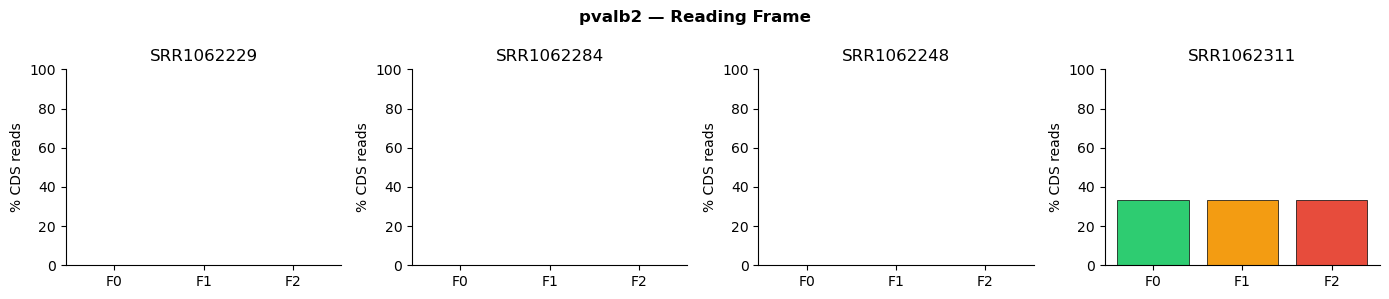

In [66]:
if cds_e > cds_s:
    cds_prof = profiles[:, cds_s:cds_e]
    fc = np.zeros((n_samples, 3))
    for f in range(3):
        fc[:, f] = cds_prof[:, f::3].sum(axis=1)

    n_plots = min(4, n_samples)
    fig, axes = plt.subplots(1, n_plots, figsize=(3.5*n_plots, 3))
    if n_plots == 1: axes = [axes]
    colors = ['#2ecc71','#f39c12','#e74c3c']
    for i, ax in enumerate(axes):
        tot = fc[i].sum()
        pct = fc[i]/tot*100 if tot > 0 else fc[i]
        ax.bar([0,1,2], pct, color=colors, ec='black', lw=0.5)
        ax.set(xticks=[0,1,2], xticklabels=['F0','F1','F2'],
               ylabel='% CDS reads', ylim=(0,100), title=sel_samples[i])
        ax.spines[['top','right']].set_visible(False)
    fig.suptitle(f"{gene['gene_name']} — Reading Frame", fontweight='bold')
    plt.tight_layout()
else:
    print('No CDS — skipping frame analysis')